# 16.2.2 集合外失效与鲁棒证据边界

## 学习目标与先修知识

辨认候选矩阵（matrix）集合、共同证书和集合外反例。

先修：16.2.1 顶点条件；特征值（eigenvalue）与二次型。

## 具体问题

两个顶点都通过共同证书，能否把超出给定参数（parameter）集合的模型（model）也称为已经保证稳定？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型对照。

In [2]:
for a in [-.8,-.4,.2]:print(a,"对角第一方向增长率",a)

-0.8 对角第一方向增长率 -0.8
-0.4 对角第一方向增长率 -0.4
0.2 对角第一方向增长率 0.2


## 模型假设

仍用上节 $P=I$ 和 $A_0,A_1$；额外矩阵 $A_{\rm out}$ 的第一对角元素为正，明确位于参数集合外。比较只涉及线性无饱和系统。

## 数学解释与推导

在区间内顶点条件保证 $x^\mathsf TPx$ 下降；对集合外矩阵没有同一保证。某个候选证书未通过不等于系统必不稳定，因为可能存在其他 P；但若某实际矩阵已有正实部特征值，则可直接构造失稳方向。鲁棒性主张必须与不确定集合、输入（input）限制及性能量相绑定。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def common_quadratic(vertices,P):
    matrix=np.asarray(P,dtype=float)
    smallest=float(np.linalg.eigvalsh(matrix)[0])
    margins=[]
    for A in vertices:
        A=np.asarray(A,dtype=float)
        symmetric=A.T@matrix+matrix@A
        margins.append(float(np.linalg.eigvalsh(symmetric)[-1]))
    return [smallest,margins,smallest>0 and all(value<0 for value in margins)]


def affine_vertex(A0,A1,alpha):
    return ((1-alpha)*np.asarray(A0,dtype=float)+alpha*np.asarray(A1,dtype=float)).tolist()

## 对照实验

从相同初态出发，比较两个区间顶点与一个集合外矩阵的轨迹（trajectory），再将变化方向与特征值对照。

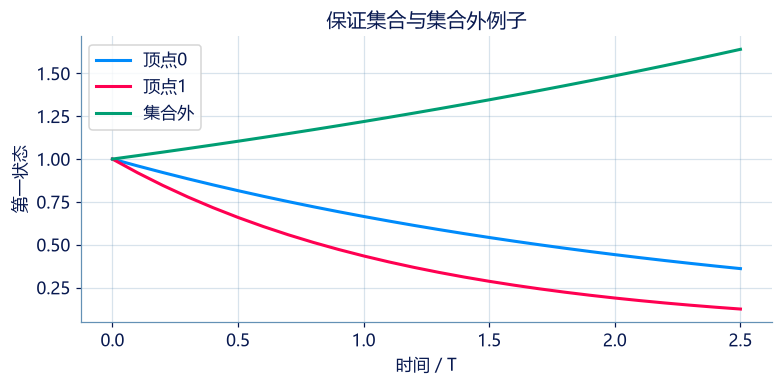

三种矩阵的共同函数余量： [-0.7585786437626905, -0.983772233983162, 0.40710678118654753]


In [4]:
A0=[[-.4,.1],[0.,-.5]];A1=[[-.8,.1],[0.,-.5]];outside=[[.2,.1],[0.,-.5]];P=np.eye(2)
rows=[("顶点0",A0),("顶点1",A1),("集合外",outside)]
fig,ax=plt.subplots(figsize=(7,3.4))
for label,A in rows:
    x=np.array([1.,0.]);path=[x[0]]
    for _ in range(25):x=x+.1*np.asarray(A)@x;path.append(x[0])
    ax.plot(np.arange(26)*.1,path,label=label)
ax.set(xlabel="时间 / T",ylabel="第一状态",title="保证集合与集合外例子");ax.legend();ax.grid(alpha=.25);plt.show()
print("三种矩阵的共同函数余量：",common_quadratic([A for _,A in rows],P)[1])

## 结果解释

集合外曲线增长与正特征值一致；这不否定先前对给定区间的证明。若候选 P 失败，仅能说当前证书未建立，不能自动宣布系统失稳。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert common_quadratic([A0,A1],P)[2]
assert not common_quadratic([A0,A1,outside],P)[2]
assert max(np.linalg.eigvals(np.asarray(outside)).real)>0
print("集合内证书与集合外特征值反例独立核验。")

集合内证书与集合外特征值反例独立核验。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：当前证书不通过意味着什么

某个候选 P 的 AᵀP+PA 有非负方向，哪项结论严谨？

- **A.** 系统在所有 P 下必失稳。
- **B.** 不确定集合可自动扩大。
- **C.** 当前 P 未建立所需严格条件，需另找证据。
- **D.** 该矩阵（matrix）一定不可对角化。

[作答：当前证书不通过意味着什么](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-certificate-failure)

### 第 2 题 · 单项选择题：集合外矩阵

区间内共同证书成立，集合外一个矩阵（matrix）出现正实部特征值（eigenvalue），应如何解释？

- **A.** 推翻区间内证明。
- **B.** 说明数值画图一定错误。
- **C.** 说明所有模型（model）都不稳定。
- **D.** 区间内保证仍成立；外部模型需另作分析。

[作答：集合外矩阵](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-outside-set)

### 第 3 题 · Python 计算题：证书与集合外反例

检验给定矩阵（matrix）集合的共同 P；返回数值条件而非猜测其他 P 的存在性。

**函数与代码模板**

```python
def solve(
    vertices: list[list[list[float]]],
    P: list[list[float]],
) -> list:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `vertices` | `list[list[list[float]]]` | 已声明集合的二维顶点。 | 1/T |
| `P` | `list[list[float]]` | 共同候选矩阵。 | 按状态尺度 |

**返回值**

直接返回 result（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list` | P 最小特征值（eigenvalue）、顶点导数（derivative）矩阵最大特征值及判定。 | 混合 |

**计算规则**

P 最小特征值应为正；逐顶点计算对称矩阵 AᵀP+PA 的最大特征值，均严格小于0才返回 True。

**约束与边界**

- 至少一个二维实矩阵顶点；P 为二维实对称候选矩阵；所有输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| vertices | 已声明集合的二维顶点。 | [[[-1.0, 0.0], [0.0, -2.0]], [[0.1, 0.0], [0.0, -1.0]]] | 1/T |
| P | 共同候选矩阵。 | [[1.0, 0.0], [0.0, 1.0]] | 按状态尺度 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
vertices = [[[-1.0, 0.0], [0.0, -2.0]],
            [[0.1, 0.0], [0.0, -1.0]]]
P = [[1.0, 0.0], [0.0, 1.0]]

result = solve(vertices, P)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | P 最小特征值（eigenvalue）、顶点导数（derivative）矩阵最大特征值及判定。 | [1.0, [-2.0, 0.2], False] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, [-2.0, 0.2], False]
```

**样例解释**

首例第二顶点有正向导数，当前 P 不能建立严格共同证书。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：证书与集合外反例](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-certificate-counterexample)

### 第 4 题 · Python 计算题：仿射不确定性下的矩阵

只在给定区间内用凸组合构造矩阵（matrix）；外部参数（parameter）不享受该证书。

**函数与代码模板**

```python
def solve(
    A0: list[list[float]],
    A1: list[list[float]],
    alpha: float,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `list[list[float]]` | 端点矩阵。 | 1/T |
| `A1` | `list[list[float]]` | 端点矩阵。 | 1/T |
| `alpha` | `float` | 区间权重。 | 1 |

**返回值**

直接返回 matrix（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 仿射（affine）矩阵。 | 1/T |

**计算规则**

逐元素计算 (1-alpha)*A0+alpha*A1。

**约束与边界**

- A0、A1 为二维实矩阵；0≤alpha≤1；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 端点矩阵。 | [[-1.0, 0.0], [0.0, -2.0]] | 1/T |
| A1 | 端点矩阵。 | [[-0.5, 0.0], [0.0, -1.0]] | 1/T |
| alpha | 区间权重。 | 1 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = [[-1.0, 0.0], [0.0, -2.0]]
A1 = [[-0.5, 0.0], [0.0, -1.0]]
alpha = 1.0

result = solve(A0, A1, alpha)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 仿射（affine）矩阵。 | [[-0.5, 0.0], [0.0, -1.0]] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[-0.5, 0.0], [0.0, -1.0]]
```

**样例解释**

α=1 返回第二端点；这里只执行矩阵构造，不自行推出稳定性。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：仿射不确定性下的矩阵](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-robust-interpolation)

**进一步阅读**

[Boyd 等](https://web.stanford.edu/~boyd/lmibook/)：线性矩阵不等式与控制分析。